In [63]:
import mido
from mido import MidiFile
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
import pychord


frequency is hardcoded to 4 / quarter note in the get_piano_roll call

In [64]:
def unpack_midi(midi_filename):
    """ 
    arguments: path to a midi file
    returns: four matrices S, A, T, B of dimension (num_pitches) x (num quarter notes) containing note info for each part
    #also return a vector for each of base chord (e.g. B not B7) over time
    """

    #load in the file
    mid = MidiFile(Path('midi files', midi_filename+'.mid'))

    #get parameters
    meta_track = mid.tracks[0] #grab the track that stores the metadata
    for msg in meta_track:
        #grab the tempo
        if msg.type == 'set_tempo': 
            tempo = msg.tempo
        elif msg.type == 'time_signature':
            numerator = msg.numerator
            denominator = msg.denominator

        #is there anything else we want from this? apparently key signature will sometimes be here    

    PPQ = mid.ticks_per_beat #get PPQ (samples per quarter note)

    length_sec = mid.length #length of the track in seconds
    
    length_ticks = mido.second2tick(length_sec, PPQ, tempo) #turns the length of the file in seconds to the length of the file in ticks?

    #calculate the number of beats
    num_beats = int(length_ticks / PPQ)

    metadata = [tempo, PPQ, length_ticks, (numerator, denominator)]
    #initialize list of output arrays
    #assumes will be returned in SATB order
    list_of_parts = []
    
    #unpack each vocal part
    for i in range(1, len(mid.tracks)): #loop over all non-metadata tracks
        track = mid.tracks[i] #index into the right part of the midi file (one indexed)

        #frequency is hardcoded to 4 times per quarter note
        list_of_parts.append(get_piano_roll(track, PPQ, 4, num_beats))

    return list_of_parts, metadata

In [65]:
#used AI for this. Really struggled to implement it on my own. I feel good about how much I understand it though
def get_piano_roll(track, PPQ, freq, num_beats, plot=False):
    total_samples = freq * num_beats
    output_array = np.zeros((128, total_samples))
    
    # Track the "start time" of currently active notes
    # stores {note_number: start_sample_index}
    open_notes = {}
    absolute_tick = 0

    for msg in track:
        absolute_tick += msg.time
        
        # Convert absolute MIDI ticks to our matrix column index
        current_sample = int((absolute_tick * freq) / PPQ)

        is_note_on = (msg.type == 'note_on' and msg.velocity > 0)
        is_note_off = (msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0))

        if is_note_on:
            # If the note was already "on", close it first (prevents stuck notes)
            if msg.note not in open_notes:
                open_notes[msg.note] = current_sample
                
        elif is_note_off:
            if msg.note in open_notes:
                start_sample = open_notes.pop(msg.note)
                end_sample = current_sample
                
                # Fill the duration of the note
                if end_sample > start_sample:
                    output_array[msg.note, start_sample:end_sample] = 1
        
        if current_sample >= total_samples:
            break

    # if a note was never turned off, extend it to the end
    for note, start_sample in open_notes.items():
        output_array[note, start_sample:] = 1

    if plot:
        plt.figure(figsize=(12, 6))
        plt.imshow(output_array, aspect='auto', origin='lower', cmap='gray_r')
        plt.xlabel('Time (Samples)')
        plt.ylabel('MIDI Pitch')
        plt.show()
        
    return output_array

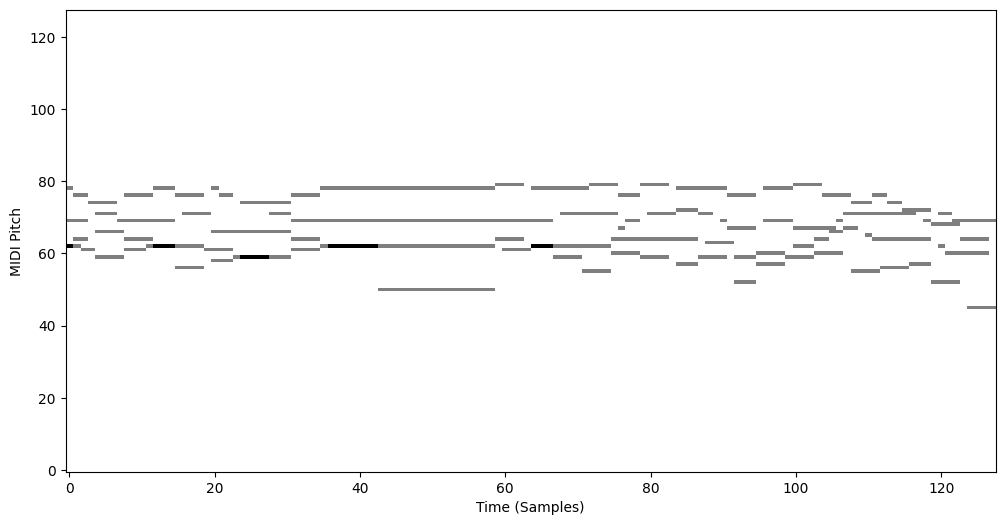

In [66]:
[S, A, T, B], metadata = unpack_midi('mix')
roll = S+A+T+B

plt.figure(figsize=(12, 6))
plt.imshow(roll, aspect='auto', origin='lower', cmap='gray_r')
plt.xlabel('Time (Samples)')
plt.ylabel('MIDI Pitch')
plt.show()

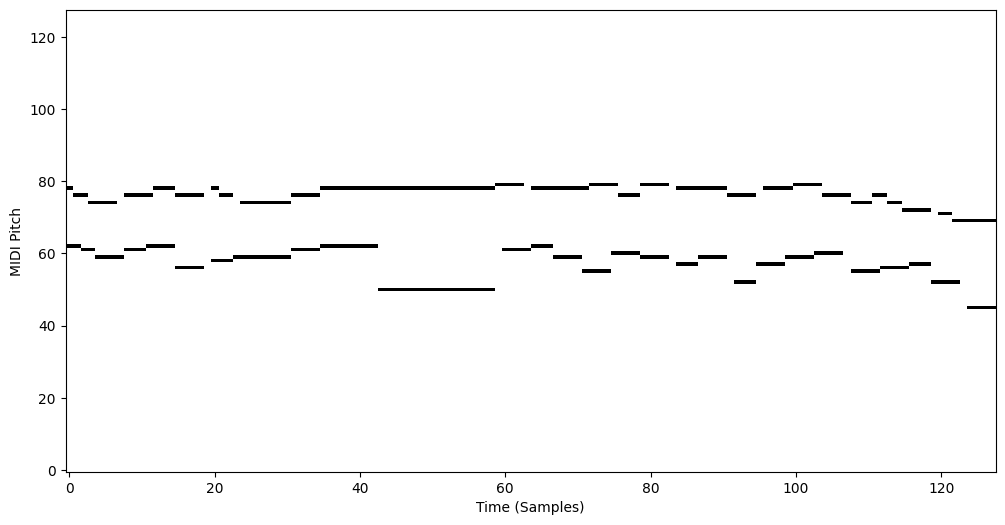

In [67]:
#just sense checking to make sure the soprano and bass parts are where I think they are.
plt.figure(figsize=(12, 6))
plt.imshow(S+B, aspect='auto', origin='lower', cmap='gray_r')
plt.xlabel('Time (Samples)')
plt.ylabel('MIDI Pitch')
plt.show()

## Approximations

1. Since pychord.analyzer.find_chords_from_notes requires an ordered chord, I just made an arbitrary choice that the soprano note is the root note. I tried to choose the bass note, but then I got a lot of Am/G "over" type chords. 
2. If pychord.analyzer.find_chords_from_notes() returns two chords, we just always take the first one. We could improve this by figuring out which transitions (where am I coming from, where am I going) are more likely using distance in the circle of fifths

# things that should be implemented still

1. how do we find the key of the song? since each song in the dataset is in one key, we could just see what notes pop up and see what scale those correspond to? this could be an operation on the roll matrix. also seems very vibe-code friendly since this is almost certainly a solved problem.
2. sometimes roll_to_chord returns strings like 'E' instead of chord objects. idk what's up with that
3. roll_to_chord still has some voicing information. This is useful long term, but for now if we want to collapse into major/minor, we need to figure out how we want to treat other types of chords (augmented, diminished, no5). Usually the built in find_chords function returns a one element list, so you'll want to index into the list then do chord.quality
4. need to transpose chords to C for easy integration into Korin's code (I think this is what we agreed on). I think this can be done with a chord.transpose method if we know the key signature
5. For the chord to idx, do we care what chord is assigned the zero index? I think there's a convention to choose C, but maybe we dgaf


In [184]:
def index_to_note(midi_index, roots=['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']):
    names = roots
    return f"{names[midi_index % 12]}"

def rearrange_chord(chord, root):
    """takes a base note and chord and returns the notes sorted in ascending order"""
    names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    positions = pychord.analyzer.notes_to_positions(chord, root)
    positions = [position % 12 for position in positions] #change to normalize by base note
    root_index = names.index(root)
    output_chord = []

    for i in range(len(positions)):
        position = min(positions) #grab the smallest position (closest to base note)
        positions.remove(position) #remove it
        output_chord.append(names[(root_index+position) % 12])
    return output_chord


def roll_to_chord(roll):
    """ arguments: takes a piano roll matrix 
    returns a tuple of chords and indices
    """

    pitches, samples = roll.shape
    output = []

    for i in range(samples):
        indices = np.nonzero(roll[:, i])[0] #this returns a tuple of an array, the first thing is the stuff we want

        notes = []
        for j in range(len(indices)): #for each midi index, turn that into a note
            notes.append(index_to_note(indices[j]))

        #turn the notes into a chord
        ordered_notes = rearrange_chord(notes, notes[0]) #assume the bass note is the bottom note
        chord = pychord.analyzer.find_chords_from_notes(ordered_notes) #can have it just return the notes

        #transpose the chord so it's in C major
        if chord != []:
            if len(chord) == 1:
                output.append((i, chord[0].root)) #return the chord with its timestamp
                # TODO: update so it can do minor chords, 7ths, etc

            else: #if there are multiple suggested chords
                output.append((i, chord[0].root)) #just take the first guess? could improve with circle of fifths knowledge

    return output

In [185]:
chords = roll_to_chord(roll)
print(chords)
print(type(chords[0]))
print(type(chords[0][0]))
print(type(chords[0][1]))


#looks like it doesn't always give us a well defined chord. Might have to find moments when they hold?

[(0, 'D'), (12, 'D'), (13, 'D'), (14, 'D'), (16, 'G#'), (17, 'G#'), (18, 'G#'), (21, 'A#'), (22, 'A#'), (23, 'B'), (24, 'B'), (25, 'B'), (26, 'B'), (27, 'B'), (35, 'D'), (36, 'D'), (37, 'D'), (38, 'D'), (39, 'D'), (40, 'D'), (41, 'D'), (42, 'D'), (60, 'C#'), (61, 'C#'), (62, 'C#'), (63, 'A'), (64, 'D'), (65, 'D'), (66, 'D'), (67, 'B'), (71, 'G'), (75, 'C'), (79, 'E'), (83, 'E'), (84, 'A'), (85, 'A'), (86, 'A'), (89, 'B'), (90, 'B'), (95, 'A'), (106, 'C'), (107, 'E'), (109, 'G'), (110, 'G'), (113, 'G#'), (114, 'G#'), (115, 'C'), (117, 'A'), (119, 'E'), (120, 'E'), (121, 'C'), (122, 'A'), (123, 'A')]
<class 'tuple'>
<class 'int'>
<class 'str'>


In [70]:
def big_parent_function(filename):
    [S, A, T, B], metadata = unpack_midi(filename)

    chords = roll_to_chord(S+A+T+B)

    #TODO get consistent chord information from SATB information
    #TODO shift to normalize chords


In [111]:
# def chordToIdxDict(key, C=14):
#     """
#     Input:
#         - key: string specifying key (eg "Cmaj", "Dmin")
#         - C: number of unique chords in key signatures
#     Output:
#         - dictionary mapping 14 key strings to their index 
#     """
#     chordDict = {}
#     for idx in range(int(C/2)):
#         major_chord = pychord.Chord.from_note_index(idx+1, "", key)
#         minor_chord = pychord.Chord.from_note_index(idx+1, "m", key)

#         chordDict[str(major_chord)] = 2*idx
#         chordDict[str(minor_chord)] = 2*idx+1
#     return chordDict

def getRootToIdxDict(roots = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']):
    """
    Input:
        - roots: list specifying potential chord roots, with each root represented as a string
                      (e.g. 'A' or 'C#)
        - C: number of unique chords in key signatures
    Output:
        - root_to_idx: dictionary mapping chord root to its index
    """
    root_to_idx = {r: i for i, r in enumerate(roots)}
    # alias enharmonic spellings (flats + theoretical E#/B#/Cb/Fb) to a canonical index
    enharmonic_aliases = {
        'Db': 'C#', 'Eb': 'D#', 'Gb': 'F#', 'Ab': 'G#', 'Bb': 'A#',
        'E#': 'F',  'B#': 'C',  'Cb': 'B',  'Fb': 'E',
    }
    for alias, canonical in enharmonic_aliases.items():
        root_to_idx[alias] = root_to_idx[canonical]
    return root_to_idx

In [171]:
dict = getRootToIdxDict()
print(dict)


{'C': 0, 'C#': 1, 'D': 2, 'D#': 3, 'E': 4, 'F': 5, 'F#': 6, 'G': 7, 'G#': 8, 'A': 9, 'A#': 10, 'B': 11, 'Db': 1, 'Eb': 3, 'Gb': 6, 'Ab': 8, 'Bb': 10, 'E#': 5, 'B#': 0, 'Cb': 11, 'Fb': 4}


In [ ]:
def getChordRoll(chords, sampDur, chordToIdxDict=dict):
    """
    Inputs:
        - chords: List (sampDur x 2) of tuples of the form (sample, chord_root) (with dtypes (int,str))
        - sampDur: duration of original audio, in samples (typically quarter notes)
        - chordToIdxDict: dictionary mapping {chord_identifier:index(int)}
    Outputs:
        - chord_roll: (C x sampDur) matrix specifying the activated chord(s) at each time sample
    """
    C = len(chordToIdxDict)
    # sampDur = chords[-1][0] + 1
    chord_roll = np.zeros((C, sampDur))

    for (samp, chord) in chords:
        chord_idx = chordToIdxDict[chord]
        try:
            chord_roll[chord_idx, samp] = 1
        except:
            print("Chord construction failed!")
            print(f"chord index: {chord_idx}")
            print(f"sample number: {samp}")


    return chord_roll
    
def get_chord_roll_and_S(midi_path):
    """
    End-to-end pipeline that turns a MIDI file into chord_roll and soprano line piano_roll 

    arguments:
        midi_path: path (str or Path) to a .mid file, e.g. 'dataset/1/song001/mix.mid'
    returns:
        chord_roll: list of chord strings (one per 16th-note sample where a chord was
                    identified), e.g. ['D', 'D', 'Bm', 'G', 'Cmaj7', ...]
        S: matrix specifying piano roll for just soprano part
    """
    [S, A, T, B], _metadata = unpack_midi(midi_path)
    roll = S+A+T+B
    sampDur = len(S)
    chord_strs = roll_to_chord(roll)
    chord_to_idx_dict = getRootToIdxDict()
    chord_roll = getChordRoll(chord_strs, sampDur, chord_to_idx_dict)
    return chord_roll, S

128
[(0, 'D'), (12, 'D'), (13, 'D'), (14, 'D'), (16, 'G#'), (17, 'G#'), (18, 'G#'), (21, 'A#'), (22, 'A#'), (23, 'B'), (24, 'B'), (25, 'B'), (26, 'B'), (27, 'B'), (35, 'D'), (36, 'D'), (37, 'D'), (38, 'D'), (39, 'D'), (40, 'D'), (41, 'D'), (42, 'D'), (60, 'C#'), (61, 'C#'), (62, 'C#'), (63, 'A'), (64, 'D'), (65, 'D'), (66, 'D'), (67, 'B'), (71, 'G'), (75, 'C'), (79, 'E'), (83, 'E'), (84, 'A'), (85, 'A'), (86, 'A'), (89, 'B'), (90, 'B'), (95, 'A'), (106, 'C'), (107, 'E'), (109, 'G'), (110, 'G'), (113, 'G#'), (114, 'G#'), (115, 'C'), (117, 'A'), (119, 'E'), (120, 'E'), (121, 'C'), (122, 'A'), (123, 'A')]
21


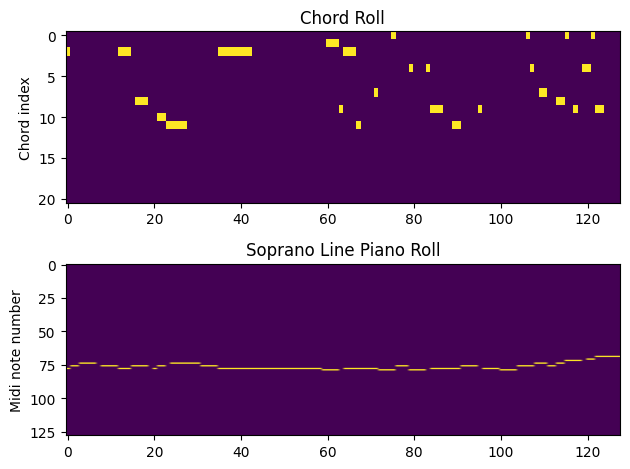

In [193]:
midi_path = "dataset/1/train/string_track000001/mix"
midi_path = "midifiles/mix"
chord_roll, S = get_chord_roll_and_S(midi_path)

plt.subplot(211)
plt.title("Chord Roll")
plt.ylabel("Chord index")
plt.imshow(chord_roll, aspect='auto')
plt.subplot(212)
plt.title("Soprano Line Piano Roll")
plt.ylabel("Midi note number")
plt.imshow(S, aspect='auto')
plt.tight_layout()


In [ ]:
print(chords[4])
chord = chords[4][1][0]
chord.info()

(16, [<Chord: G#dim6>, <Chord: E7/G#>])


'G#dim6\nroot=G#\nquality=dim6\nappended=[]\non='

In [ ]:
notes = ['C', 'Eb', 'G']
chord = pychord.analyzer.find_chords_from_notes(notes)
print(chord[0].quality)

m


In [133]:
def midi_parse(midi_path):
    """
    End-to-end pipeline that turns a MIDI file into a list of chord-name strings
    suitable for the markov model in chord_to_chord_mm.py.

    arguments:
        midi_path: path (str or Path) to a .mid file, e.g. 'dataset/1/song001/mix.mid'
    returns:
        list of chord strings (one per 16th-note sample where a chord was
        identified), e.g. ['D', 'D', 'Bm', 'G', 'Cmaj7', ...]

    TODO: collapse runs of identical chords, transpose to C major using the
    song's key signature, and restrict quality to major/minor.
    """
    parts, _metadata = unpack_midi(midi_path)
    roll = sum(parts)

    chord_tuples = roll_to_chord(roll)

    chord_strings = []
    for _sample_idx, chord in chord_tuples:
        if isinstance(chord, str):
            # multi-guess fallback from roll_to_chord: already just a root name
            chord_strings.append(chord)
        else:
            # list of pychord.Chord objects; take the first one as its string form
            chord_strings.append(str(chord[0]))

    return chord_strings